# Model railroad scheduler

An original discrete-event exercise inspired by **Interactive Model Railroad**, credited to Probably Nick in the Awesome GPT-6 Astra catalog.

Sources: [original creator post](https://x.com/nickfromlater/status/2097355845524726084) · [creator live demo](https://alder-valley-rail-atelier.nickfromlater.chatgpt.site/) · [Awesome GPT-6 Astra](https://github.com/magiccreator-ai/awesome-gpt-6-astra#interactive-model-railroad)

> This notebook does not reproduce the creator's Three.js project. It explores block occupancy and timetable conflicts using plain Python.


## Look → predict → run
**Learn:** connect a timetable to spatial block occupancy.
**Predict:** can two trains have nonoverlapping names in a timetable but still occupy the same block?
Intervals use the half-open convention `[start, end)`: one train can leave exactly when another arrives.
The schedules are invented. Conflicts here are overlaps, not a complete railway safety model.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astra_utils import style, animate_tracks, COLORS
style()


Conflicts: [('West', 'Express', 'Freight'), ('Station', 'Local 1', 'Express')]


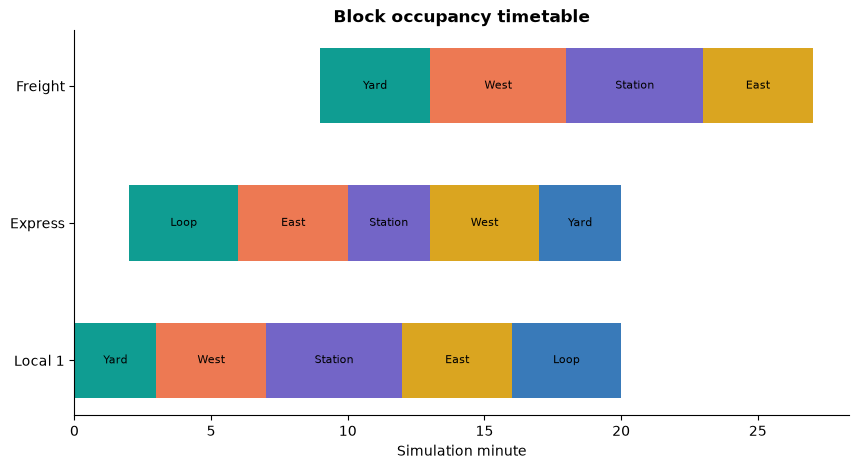

In [2]:
import matplotlib.pyplot as plt

blocks = ['Yard','West','Station','East','Loop']
routes = {
    'Local 1': [('Yard',0,3),('West',3,7),('Station',7,12),('East',12,16),('Loop',16,20)],
    'Express': [('Loop',2,6),('East',6,10),('Station',10,13),('West',13,17),('Yard',17,20)],
    'Freight': [('Yard',9,13),('West',13,18),('Station',18,23),('East',23,27)]
}

conflicts=[]
for block in blocks:
    visits=[]
    for train, legs in routes.items():
        visits += [(train,start,end) for b,start,end in legs if b==block]
    visits.sort(key=lambda x:x[1])
    for i,a in enumerate(visits):
        for b in visits[i+1:]:
            if max(a[1],b[1]) < min(a[2],b[2]):
                conflicts.append((block,a[0],b[0]))
print('Conflicts:', conflicts or 'none')

fig, ax=plt.subplots(figsize=(10,5))
for i,(train,legs) in enumerate(routes.items()):
    for block,start,end in legs:
        ax.barh(i,end-start,left=start,height=.55)
        ax.text((start+end)/2,i,block,ha='center',va='center',fontsize=8)
ax.set_yticks(range(len(routes)), labels=list(routes))
ax.set(xlabel='Simulation minute', title='Block occupancy timetable')
plt.show()


## Extension ideas
Resolve conflicts automatically with signals, waiting rules, passing sidings, priorities, or shortest-path routing across a larger track graph.


## Put the timetable back onto the track
The left panel is a schematic, not geographic coordinates. The right panel counts simultaneous trains
in each block at quarter-minute samples. Red flags two or more; exact conflicts above are interval-based,
so they do not depend on this display sampling resolution.


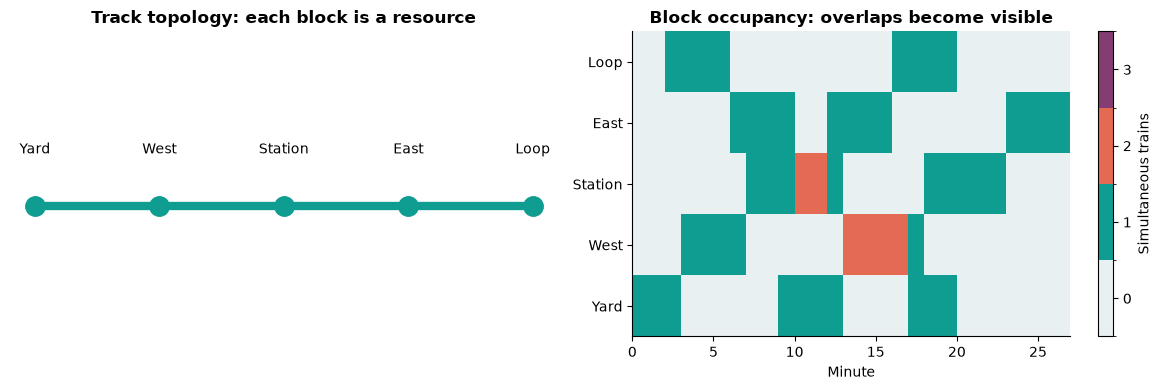

In [3]:
import numpy as np
from matplotlib.colors import ListedColormap,BoundaryNorm
time=np.arange(0,27,.25)
occupancy=np.array([[sum(b==block and start<=t<end for legs in routes.values() for b,start,end in legs) for t in time] for block in blocks])
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(np.arange(len(blocks)),np.zeros(len(blocks)),'o-',lw=6,ms=14,color='#0f9d92')
for i,block in enumerate(blocks): axes[0].text(i,.12,block,ha='center')
axes[0].set(ylim=(-.3,.4),title='Track topology: each block is a resource'); axes[0].axis('off')
im=axes[1].imshow(occupancy,origin='lower',aspect='auto',extent=(0,27,-.5,4.5),cmap=ListedColormap(['#e9f0f2','#0f9d92','#e56a54','#843d72']),norm=BoundaryNorm([-.5,.5,1.5,2.5,3.5],4))
axes[1].set_yticks(range(5),labels=blocks)
axes[1].set(xlabel='Minute',title='Block occupancy: overlaps become visible')
fig.colorbar(im,ax=axes[1],ticks=[0,1,2,3],label='Simultaneous trains')
fig.tight_layout(); plt.show()
assert {c[0] for c in conflicts} == {'Station','West'}


**Experiment:** delay Express by three minutes and recompute all conflicts. Does solving one overlap
create another? A timetable is a coupled system: local changes can propagate across the network.
Continue to notebook 09 to add route choice and weighted graph search.
